<a href="https://colab.research.google.com/github/Jayaprakash012/PREDICTION-OF-BUILDINGS-DAILY-ENERGY-CONSUMPTION/blob/main/minsquare_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2556281738.py:25: RuntimeWarning: invalid value encountered in sqrt
  dist = np.sqrt((point[0]-new_point[0])*2 + (point[1]-new_point[1])*2)


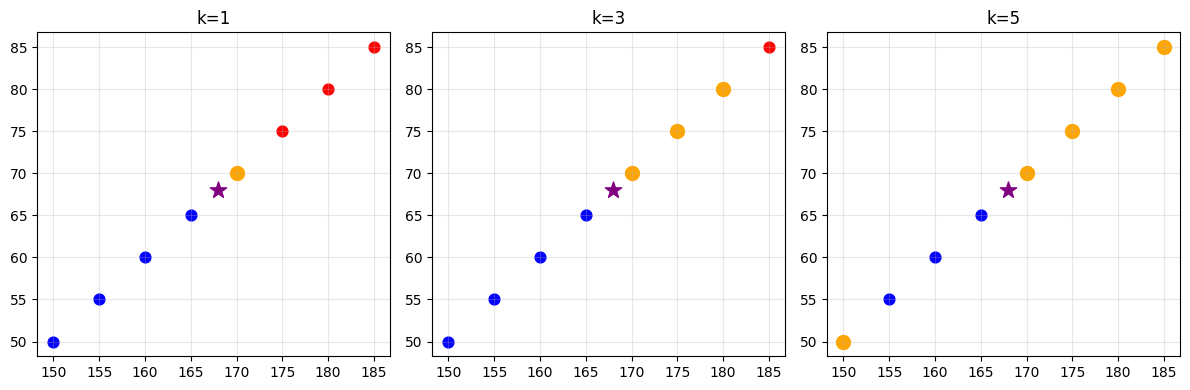

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
    [150, 50],
    [155, 55],
    [160, 60],
    [165, 65],
    [170, 70],
    [175, 75],
    [180, 80],
    [185, 85]
])

labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])
new_point = np.array([168, 68])

plt.figure(figsize=(12, 4))

k_values = [1, 3, 5]

for i, k in enumerate(k_values):
    distances = []
    for point, label in zip(data, labels):
        dist = np.sqrt((point[0]-new_point[0])*2 + (point[1]-new_point[1])*2)
        distances.append((dist, label))

    distances.sort()
    neighbors = distances[:k]

    votes = [label for _, label in neighbors]
    result = max(set(votes), key=votes.count)

    plt.subplot(1, 3, i+1)

    plt.scatter(data[labels==0, 0], data[labels==0, 1], c='blue', s=60, label='Short')
    plt.scatter(data[labels==1, 0], data[labels==1, 1], c='red', s=60, label='Tall')

    neighbor_indices = np.argsort([d[0] for d in distances])[:k]
    plt.scatter(data[neighbor_indices, 0], data[neighbor_indices, 1],
                c='orange', s=100, label=f'Nearest {k}')

    plt.scatter(new_point[0], new_point[1],
                c='green' if result==1 else 'purple',
                s=150, marker='*', label=f'Pred: {"Tall" if result==1 else "Short"}')

    plt.title(f'k={k}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()